# Detector-triggered switching: cost under honesty, benefit under persuasion

Four listener policies ran on **one utterance stream per simulation** (paired):

| policy | what it is |
|---|---|
| `cred` | credulous L1, $\psi=\{\text{inf}\}$ throughout (Fang's coop listener) |
| `vig` | vigilant L1, $\psi=\{\text{inf},\text{high},\text{low}\}$ from round 1 (Fang's strat listener) |
| `soft` | credulous until `sus_1` fires at $\tau$; then vigilant, inheriting the credulous $\theta$-marginal |
| `hard` | credulous until $\tau$; then vigilant from a uniform joint prior |

Two questions. Under an **honest** speaker, how much does each policy pay
relative to `cred` (the vigilance *cost*)? Under a **persuasive** speaker, how
much of the gap between `cred` and `vig` does switching recover (the vigilance
*benefit*), and how does that depend on when the detector fires?

Every policy's full $\theta$-marginal is stored per round, so the metrics below
($|E[\theta]-\theta^\star|$, $P(\theta^\star)$) are derived here and others can be
added without re-running.

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path().resolve())
    while p != p.parent:
        if (p / 'experiments' / 'full_sweep').exists():
            return p
        p = p.parent
    raise RuntimeError('repo root not found')


ROOT = _find_repo_root()
RES_DIR = ROOT / 'results/switching_smoke'
TRAJ_DIR = RES_DIR / 'trajectories'
SIMS_DIR = RES_DIR / 'simulations'
OUT_DIR = RES_DIR / 'analyses'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = json.loads((RES_DIR / 'run_config.json').read_text())
T_MAX = int(CFG['grid']['rounds'])
N_SIMS = int(CFG['grid']['n_sims_per_cell'])
C_SWITCH = CFG['switch']['c']
THETAS = np.array(CFG['theta_space'], dtype=float)
NT = len(THETAS)
PSIS = ['inf', 'high', 'low']
POLICIES = ['cred', 'vig', 'soft', 'hard']
PSI_POL = ['vig', 'soft', 'hard']
COLOR = {'cred': 'tab:red', 'vig': 'tab:blue', 'soft': 'tab:green', 'hard': 'tab:orange'}
PSI_CODE = {'inf': 'inf', 'pers+': 'high', 'pers-': 'low'}


def save(fig, name):
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')


print(f'results  {RES_DIR}')
print(f'T={T_MAX}  sims/cell={N_SIMS}  c_switch={C_SWITCH}  status={CFG["status"]}')

results  D:\Research\argumentative-awareness\results\switching_smoke
T=30  sims/cell=4  c_switch=3.5  status=complete


## 0 — Load as panels

Same trick as `stopping_rules.ipynb`: shards are streamed one at a time and
reduced to dense `(n_sims_total, T)` panels of the metrics we need, so memory is
a few hundred MB regardless of grid size instead of the ~5 GB the raw 64-column
frame would cost.

In [2]:
def load_panels():
    shards = sorted(TRAJ_DIR.glob('cell=*/part.parquet'))
    n = len(shards) * N_SIMS
    ERR = {p: np.empty((n, T_MAX), np.float32) for p in POLICIES}   # |E[theta]-theta*|
    PT  = {p: np.empty((n, T_MAX), np.float32) for p in POLICIES}   # P(theta*)
    PSI = {p: np.full((n, T_MAX), np.nan, np.float32) for p in PSI_POL}  # P(psi = true psi)
    PINF = {p: np.full((n, T_MAX), np.nan, np.float32) for p in PSI_POL} # P(psi = inf)
    SW = np.zeros((n, T_MAX), bool)
    meta = []
    th_cols = {p: [f'{p}_theta_{i}' for i in range(NT)] for p in POLICIES}
    psi_cols = {p: [f'{p}_psi_{q}' for q in PSIS] for p in PSI_POL}
    for k, path in enumerate(shards):
        d = pd.read_parquet(path)
        lo, hi = k * N_SIMS, (k + 1) * N_SIMS
        th_star = float(d['theta_star'].iloc[0])
        psi_true = str(d['psi_true'].iloc[0])
        j_star = int(np.argmin(np.abs(THETAS - th_star)))
        j_psi = PSIS.index(PSI_CODE[psi_true])
        for p in POLICIES:
            M = d[th_cols[p]].to_numpy().reshape(N_SIMS, T_MAX, NT)
            ERR[p][lo:hi] = np.abs(M @ THETAS - th_star)
            PT[p][lo:hi] = M[:, :, j_star]
        for p in PSI_POL:
            P = d[psi_cols[p]].to_numpy().reshape(N_SIMS, T_MAX, len(PSIS))
            PSI[p][lo:hi] = P[:, :, j_psi]
            PINF[p][lo:hi] = P[:, :, 0]
        SW[lo:hi] = d['switched'].to_numpy().reshape(N_SIMS, T_MAX).astype(bool)
        s = pd.read_parquet(SIMS_DIR / path.parent.name / 'part.parquet')
        meta.append(s[['cell_id', 'sim_id', 'theta_star', 'psi_true', 'alpha', 'tau']])
        del d
    meta = pd.concat(meta, ignore_index=True)
    return meta, ERR, PT, PSI, PINF, SW


%time meta, ERR, PT, PSI, PINF, SW = load_panels()
ROUNDS = np.arange(1, T_MAX + 1)
mb = sum(a.nbytes for D in (ERR, PT, PSI, PINF) for a in D.values()) / 1e6
print(f'sims {len(meta):,}   panel memory {mb:.0f} MB')

IS_NULL = (meta.psi_true == 'inf').to_numpy()
IS_ALT = ~IS_NULL
ALPHAS = np.array(sorted(meta.alpha.unique()))
THETA_STARS = np.array(sorted(meta.theta_star.unique()))
TAU = meta['tau'].to_numpy()
FIRED = TAU >= 0

# self-checks
assert np.allclose(ERR['soft'][~SW], ERR['cred'][~SW], atol=1e-6), 'soft != cred before tau'
assert np.allclose(ERR['hard'][~SW], ERR['cred'][~SW], atol=1e-6), 'hard != cred before tau'
print(f'switch rate: null {FIRED[IS_NULL].mean():.3f}   persuasive {FIRED[IS_ALT].mean():.3f}')

CPU times: total: 10.9 s
Wall time: 14.1 s
sims 1,188   panel memory 2 MB


switch rate: null 0.030   persuasive 0.662


## 1 — Headline table

In [3]:
def summarize(mask):
    rows = []
    for p in POLICIES:
        rows.append({'policy': p,
                     'err_T': float(ERR[p][mask, -1].mean()),
                     'err_t30': float(ERR[p][mask, min(29, T_MAX-1)].mean()),
                     'P(theta*)_T': float(PT[p][mask, -1].mean())})
    return pd.DataFrame(rows).set_index('policy')

R = {}
for name, mask in [('null (inf)', IS_NULL), ('pers+', (meta.psi_true == 'pers+').to_numpy()),
                   ('pers-', (meta.psi_true == 'pers-').to_numpy())]:
    R[name] = summarize(mask)
tab = pd.concat(R, axis=1)
tab.to_csv(OUT_DIR / 'R1_headline.csv')

# fraction of the vigilance benefit that switching recovers, persuasive cells only
ben = {}
for p in ('soft', 'hard'):
    num = ERR['cred'][IS_ALT, -1].mean() - ERR[p][IS_ALT, -1].mean()
    den = ERR['cred'][IS_ALT, -1].mean() - ERR['vig'][IS_ALT, -1].mean()
    ben[p] = num / den if den > 0 else np.nan
cost = {p: float(ERR[p][IS_NULL, -1].mean() - ERR['cred'][IS_NULL, -1].mean())
        for p in ('vig', 'soft', 'hard')}
print(tab.round(4).to_string())
print(f'\nswitch rate: null {FIRED[IS_NULL].mean():.3f}   persuasive {FIRED[IS_ALT].mean():.3f}'
      f'   median tau (persuasive, fired) {np.median(TAU[IS_ALT & FIRED]):.0f}')
print('vigilance benefit recovered at T (persuasive):  '
      + '   '.join(f'{p}: {v:.2f}' for p, v in ben.items()))
print('extra error vs cred at T under null (cost):      '
      + '   '.join(f'{p}: {v:+.4f}' for p, v in cost.items()))

       null (inf)                       pers+                       pers-                    
            err_T err_t30 P(theta*)_T   err_T err_t30 P(theta*)_T   err_T err_t30 P(theta*)_T
policy                                                                                       
cred       0.0225  0.0225      0.7627  0.1082  0.1082      0.3387  0.1018  0.1018      0.3602
vig        0.0232  0.0232      0.7506  0.0504  0.0504      0.5163  0.0496  0.0496      0.5260
soft       0.0225  0.0225      0.7623  0.0691  0.0691      0.4496  0.0684  0.0684      0.4565
hard       0.0227  0.0227      0.7605  0.0594  0.0594      0.4500  0.0639  0.0639      0.4504



switch rate: null 0.030   persuasive 0.662   median tau (persuasive, fired) 3
vigilance benefit recovered at T (persuasive):  soft: 0.66   hard: 0.79
extra error vs cred at T under null (cost):      vig: +0.0007   soft: -0.0000   hard: +0.0002


## 2 — Error over rounds: cost under honesty, benefit under persuasion

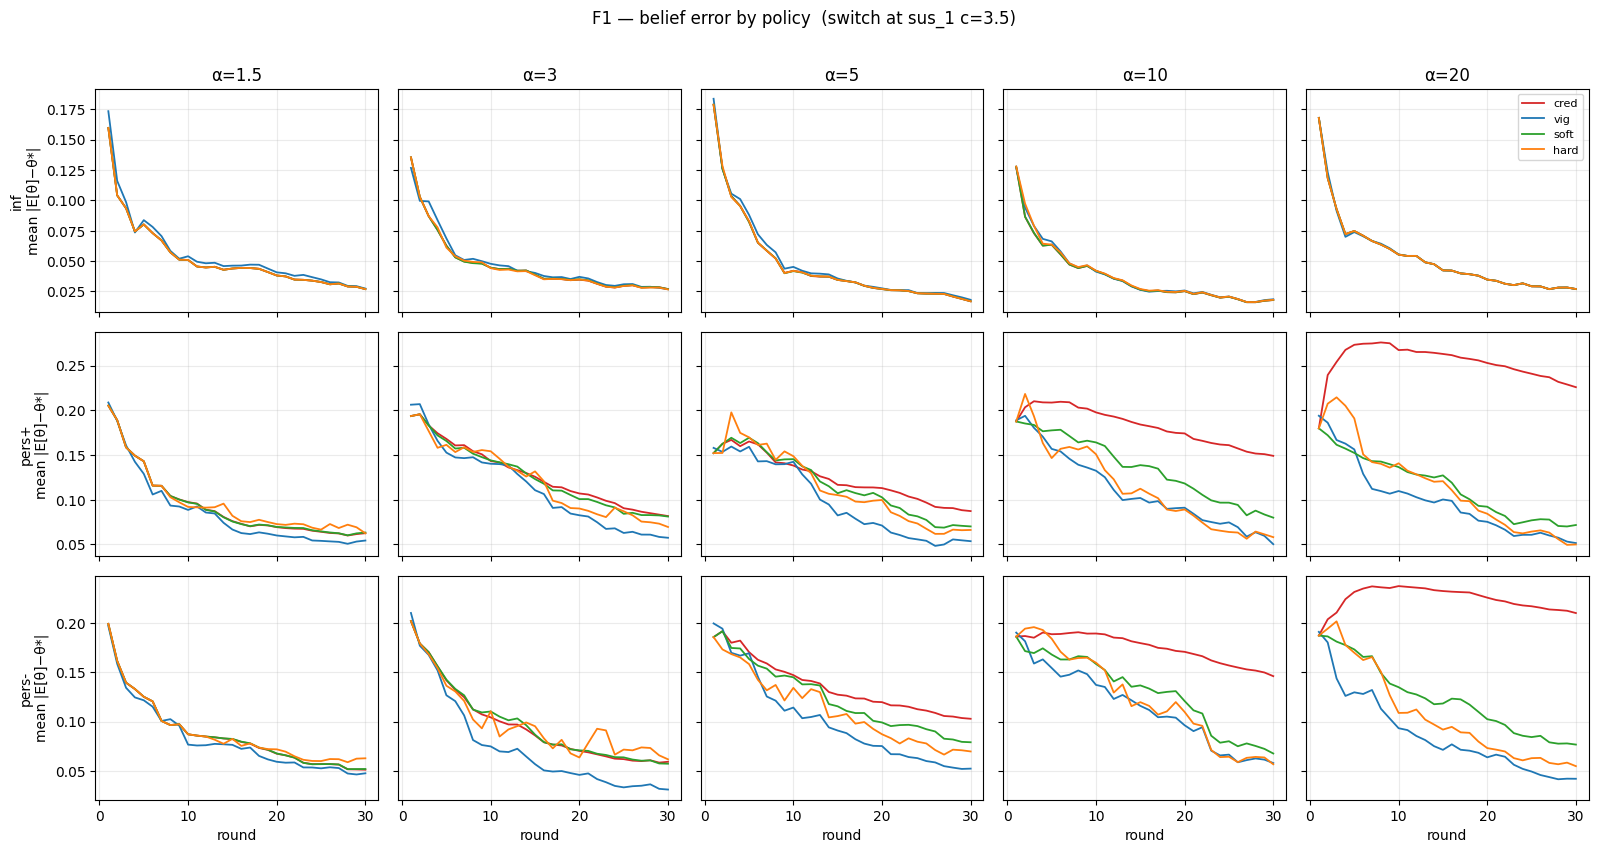

In [4]:
ALPHA_SHOW = [a for a in (1.5, 3.0, 5.0, 10.0, 20.0) if a in ALPHAS]
fig, axes = plt.subplots(3, len(ALPHA_SHOW), figsize=(3.2 * len(ALPHA_SHOW), 8.4),
                         sharex=True, sharey='row', squeeze=False)
for j, a in enumerate(ALPHA_SHOW):
    am = (meta.alpha == a).to_numpy()
    for r, (lab, m) in enumerate([('inf', IS_NULL & am),
                                  ('pers+', (meta.psi_true == 'pers+').to_numpy() & am),
                                  ('pers-', (meta.psi_true == 'pers-').to_numpy() & am)]):
        ax = axes[r, j]
        for p in POLICIES:
            ax.plot(ROUNDS, ERR[p][m].mean(axis=0), color=COLOR[p], lw=1.3, label=p)
        if r == 0: ax.set_title(f'α={a:g}')
        if j == 0: ax.set_ylabel(f'{lab}\nmean |E[θ]−θ*|')
        if r == 2: ax.set_xlabel('round')
        ax.grid(alpha=0.25)
axes[0, -1].legend(fontsize=8)
fig.suptitle(f'F1 — belief error by policy  (switch at sus_1 c={C_SWITCH})', y=1.01)
fig.tight_layout(); save(fig, 'F1_error_vs_round.png'); plt.show()

## 3 — Where the benefit lives: over the $(\theta^\star,\alpha)$ grid

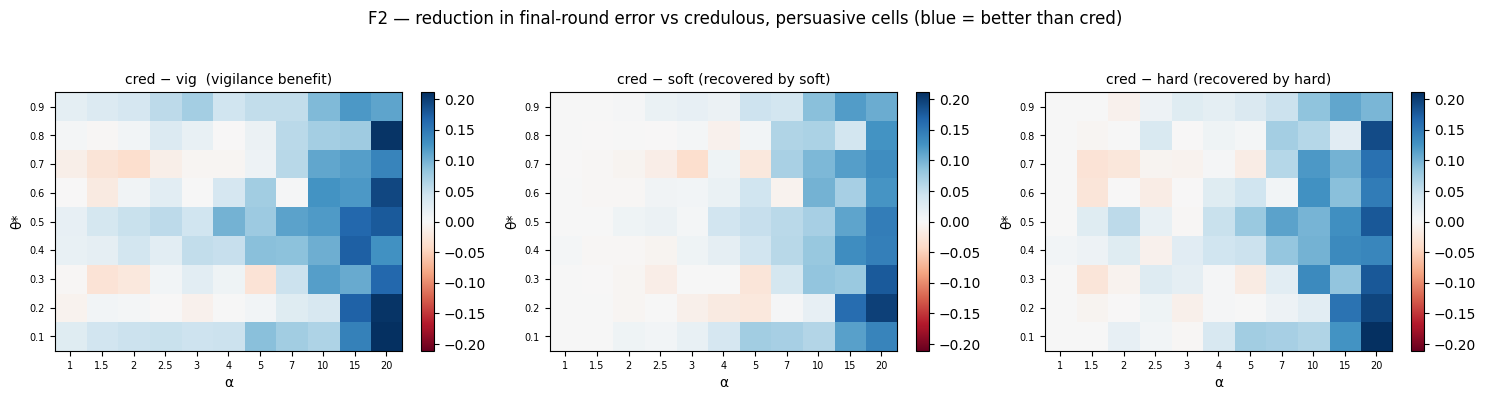

In [5]:
def grid_stat(fn):
    M = np.full((len(THETA_STARS), len(ALPHAS)), np.nan)
    for i, th in enumerate(THETA_STARS):
        for j, a in enumerate(ALPHAS):
            m = IS_ALT & (meta.theta_star == th).to_numpy() & (meta.alpha == a).to_numpy()
            if m.any(): M[i, j] = fn(m)
    return M

panels = [
    ('cred − vig  (vigilance benefit)', grid_stat(lambda m: ERR['cred'][m, -1].mean() - ERR['vig'][m, -1].mean())),
    ('cred − soft (recovered by soft)', grid_stat(lambda m: ERR['cred'][m, -1].mean() - ERR['soft'][m, -1].mean())),
    ('cred − hard (recovered by hard)', grid_stat(lambda m: ERR['cred'][m, -1].mean() - ERR['hard'][m, -1].mean())),
]
vmax = np.nanmax([np.nanmax(np.abs(P)) for _, P in panels])
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (ttl, M) in zip(axes, panels):
    im = ax.imshow(M, aspect='auto', origin='lower', cmap='RdBu', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(ALPHAS))); ax.set_xticklabels([f'{a:g}' for a in ALPHAS], fontsize=7)
    ax.set_yticks(range(len(THETA_STARS))); ax.set_yticklabels([f'{t:g}' for t in THETA_STARS], fontsize=7)
    ax.set_xlabel('α'); ax.set_ylabel('θ*'); ax.set_title(ttl, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('F2 — reduction in final-round error vs credulous, persuasive cells (blue = better than cred)', y=1.04)
fig.tight_layout(); save(fig, 'F2_benefit_grid.png'); plt.show()

## 4 — Switch timing and recovery after $\tau$

Recovery curves are aligned at the switch round, so they show how fast the
vigilant machinery pulls the belief back once it is turned on — the hard/soft
difference is entirely here.

C:\Users\onerk\AppData\Local\Temp\ipykernel_4924\2299347608.py:24: RuntimeWarning: Mean of empty slice
  ax.plot(np.arange(K), np.nanmean(acc, axis=0), color=COLOR[p], lw=1.4, label=p)


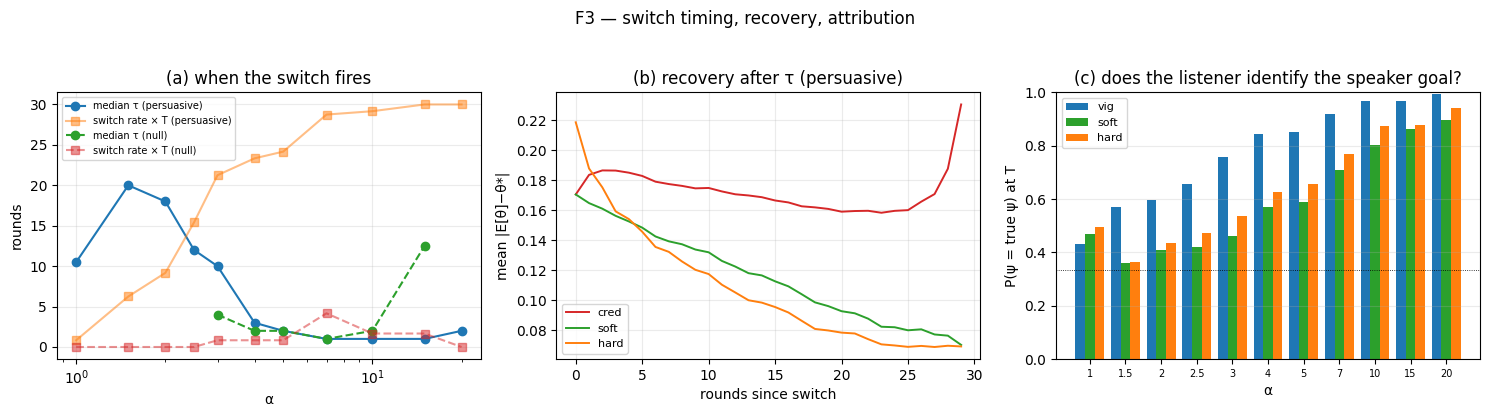

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# (a) tau distribution by alpha, persuasive vs null
ax = axes[0]
for lab, m, ls in [('persuasive', IS_ALT, '-'), ('null', IS_NULL, '--')]:
    med = [np.median(TAU[m & FIRED & (meta.alpha == a).to_numpy()])
           if (m & FIRED & (meta.alpha == a).to_numpy()).any() else np.nan for a in ALPHAS]
    ax.plot(ALPHAS, med, marker='o', ls=ls, label=f'median τ ({lab})')
    rate = [FIRED[m & (meta.alpha == a).to_numpy()].mean() for a in ALPHAS]
    ax.plot(ALPHAS, np.array(rate) * T_MAX, marker='s', ls=ls, alpha=0.5,
            label=f'switch rate × T ({lab})')
ax.set_xscale('log'); ax.set_xlabel('α'); ax.set_ylabel('rounds'); ax.grid(alpha=0.25)
ax.legend(fontsize=7); ax.set_title('(a) when the switch fires')

# (b) recovery aligned at tau, persuasive fired sims
ax = axes[1]
m = IS_ALT & FIRED
K = 60
for p in ('cred', 'soft', 'hard'):
    acc = np.full((m.sum(), K), np.nan)
    for r, idx in enumerate(np.where(m)[0]):
        t0 = TAU[idx]                       # 1-based switch round
        seg = ERR[p][idx, t0 - 1:t0 - 1 + K]
        acc[r, :len(seg)] = seg
    ax.plot(np.arange(K), np.nanmean(acc, axis=0), color=COLOR[p], lw=1.4, label=p)
ax.set_xlabel('rounds since switch'); ax.set_ylabel('mean |E[θ]−θ*|')
ax.grid(alpha=0.25); ax.legend(fontsize=8); ax.set_title('(b) recovery after τ (persuasive)')

# (c) psi attribution at T
ax = axes[2]
x = np.arange(len(ALPHAS)); w = 0.27
for k, p in enumerate(PSI_POL):
    vals = [np.nanmean(PSI[p][IS_ALT & (meta.alpha == a).to_numpy(), -1]) for a in ALPHAS]
    ax.bar(x + (k - 1) * w, vals, w, color=COLOR[p], label=p)
ax.set_xticks(x); ax.set_xticklabels([f'{a:g}' for a in ALPHAS], fontsize=7)
ax.set_xlabel('α'); ax.set_ylabel('P(ψ = true ψ) at T'); ax.set_ylim(0, 1)
ax.axhline(1/3, color='k', lw=0.6, ls=':'); ax.grid(alpha=0.25, axis='y'); ax.legend(fontsize=8)
ax.set_title('(c) does the listener identify the speaker goal?')
fig.suptitle('F3 — switch timing, recovery, attribution', y=1.03)
fig.tight_layout(); save(fig, 'F3_timing_recovery.png'); plt.show()

## 5 — Cost/benefit per cell

Each point is one $(\theta^\star,\alpha)$ cell: what a policy loses under an
honest speaker (x) against what it gains under a persuasive one (y), both at
$T$ and relative to `cred`. The ideal is top-left.

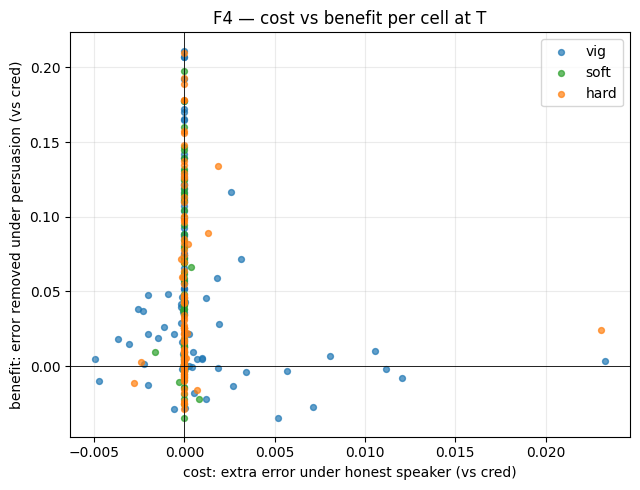

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for p in ('vig', 'soft', 'hard'):
    xs, ys = [], []
    for th in THETA_STARS:
        for a in ALPHAS:
            base = (meta.theta_star == th).to_numpy() & (meta.alpha == a).to_numpy()
            n, al = base & IS_NULL, base & IS_ALT
            if n.any() and al.any():
                xs.append(ERR[p][n, -1].mean() - ERR['cred'][n, -1].mean())
                ys.append(ERR['cred'][al, -1].mean() - ERR[p][al, -1].mean())
    ax.scatter(xs, ys, s=18, alpha=0.7, color=COLOR[p], label=p)
ax.axhline(0, color='k', lw=0.6); ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('cost: extra error under honest speaker (vs cred)')
ax.set_ylabel('benefit: error removed under persuasion (vs cred)')
ax.grid(alpha=0.25); ax.legend()
ax.set_title('F4 — cost vs benefit per cell at T')
fig.tight_layout(); save(fig, 'F4_cost_benefit.png'); plt.show()

## 6 — Reading it

Fill in after the run: does switching recover most of the vigilance benefit
where persuasion actually bites (large $\alpha$)? Is the null cost of `soft`
essentially the false-alarm rate times the vigilance cost? Where does `hard`
lose relative to `soft` — is discarding the credulous belief ever worth it?